<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-297-Natural-Language-Processing/blob/main/C1_W1_lecture_nb_01_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import nltk
from nltk.corpus import twitter_samples
import matplotlib.pyplot as plt
import random


In [3]:
nltk.download('twitter_samples')

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Unzipping corpora/twitter_samples.zip.


True

In [4]:
all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

In [5]:
print('no. of positive tweets', len(all_positive_tweets))
print('no. of negative tweets', len(all_negative_tweets))

print('the type of all_positive_tweets is', type(all_positive_tweets))
print('the type of tweet entry is', type(all_negative_tweets[0]))

no. of positive tweets 5000
no. of negative tweets 5000
the type of all_positive_tweets is <class 'list'>
the type of tweet entry is <class 'str'>


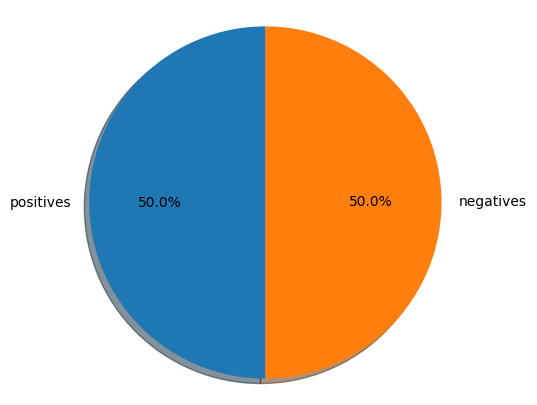

In [6]:
fig = plt.figure(figsize=(5,5))

labels = 'positives','negatives'

sizes = [len(all_positive_tweets), len(all_negative_tweets)]

plt.pie(sizes, labels=labels, autopct = '%1.1f%%', shadow=True, startangle=90)
plt.axis('equal')
plt.show()

In [7]:
print('\033[92m' + all_positive_tweets[random.randint(0,5000)])

print('\033[91m' + all_negative_tweets[random.randint(0,5000)])

@bjoernknafla @s_whiteant that’s EXACTLY the look I’m going for :D
I care :( http://t.co/Oe5ID3cJIR


In [8]:
tweet = all_positive_tweets[2277]
print(tweet)

My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i


In [9]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [10]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

In [11]:
print('\033[92m' + tweet)
print('\033[94m')

tweet2 = re.sub(r'^RT[\s]+', '', tweet)

# remove hyperlinks
tweet2 = re.sub(r'https?://[^\s\n\r]+', '', tweet2)

# remove hashtags
# only removing the hash # sign from the word
tweet2 = re.sub(r'#', '', tweet2)

print(tweet2)

My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i

My beautiful sunflowers on a sunny Friday morning off :) sunflowers favourites happy Friday off… 


In [12]:
print()
print('\033[92m' + tweet2)

tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)

tweet_tokens = tokenizer.tokenize(tweet2)

print()
print(tweet_tokens)


My beautiful sunflowers on a sunny Friday morning off :) sunflowers favourites happy Friday off… 

['my', 'beautiful', 'sunflowers', 'on', 'a', 'sunny', 'friday', 'morning', 'off', ':)', 'sunflowers', 'favourites', 'happy', 'friday', 'off', '…']


In [13]:
stopwords_english = stopwords.words('english')

print(stopwords_english)

print(string.punctuation)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [16]:
print()
print('\033[92m')
print('\033[94m')

tweets_clean = []

for word in tweet_tokens:
     if ( word not in stopwords_english and
         word not in string.punctuation):
          tweets_clean.append(word)

print(tweets_clean)







['beautiful', 'sunflowers', 'sunny', 'friday', 'morning', ':)', 'sunflowers', 'favourites', 'happy', 'friday', '…']


In [18]:
print()
print('\033[92m')
print(tweets_clean)
print('\033[94m')

stemmer = PorterStemmer()

tweets_stem = []

for word in tweets_clean:
    stem_word = stemmer.stem(word)
    tweets_stem.append(stem_word)

print(tweets_stem)



['beautiful', 'sunflowers', 'sunny', 'friday', 'morning', ':)', 'sunflowers', 'favourites', 'happy', 'friday', '…']

['beauti', 'sunflow', 'sunni', 'friday', 'morn', ':)', 'sunflow', 'favourit', 'happi', 'friday', '…']


In [20]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

# Instantiate objects once globally in this cell for efficiency
stemmer = PorterStemmer()
stopwords_english = stopwords.words('english')
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)

def process_tweet(tweet_text):
    """Process tweet function.
    Input:
        tweet_text: a string containing a tweet
    Output:
        tweets_stem: a list of stemmed words
    """
    # remove old style retweet text "RT"
    tweet_text = re.sub(r'^RT[\s]+', '', tweet_text)
    # remove hyperlinks
    tweet_text = re.sub(r'https?://[^\s\n\r]+', '', tweet_text)
    # remove hashtags
    # only removing the hash # sign from the word
    tweet_text = re.sub(r'#', '', tweet_text)

    # tokenize tweets
    tweet_tokens = tokenizer.tokenize(tweet_text)

    tweets_clean = []
    for word in tweet_tokens:
        if (word not in stopwords_english and  # remove stopwords
                word not in string.punctuation):  # remove punctuation
            tweets_clean.append(word)

    tweets_stem = []
    for word in tweets_clean:
        stem_word = stemmer.stem(word)  # stem the word
        tweets_stem.append(stem_word)

    return tweets_stem

tweet = all_positive_tweets[2277]

In [21]:
print()
print('\033[92m')
print(tweet)
print('\033[94m')

# call the imported function
tweets_stem = process_tweet(tweet); # Preprocess a given tweet

print('preprocessed tweet:')
print(tweets_stem) # Print the result



My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i

preprocessed tweet:
['beauti', 'sunflow', 'sunni', 'friday', 'morn', ':)', 'sunflow', 'favourit', 'happi', 'friday', '…']
